# Modeling the Relationship Between Climate Variables and Livestock Production in Nigeria (2000–2020): A Python Regression Analysis
# Data Sources: NASA POWER (Climate) & FAO (Livestock Production)
# Analyst: Olafimihan Bamidele John
# Tool: Python (Jupyter Notebook)

# Load Packages

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [7]:
df = pd.read_csv(r"C:\Users\test1\Downloads\Climate_Production_Data\Nigeria_Climate_Data.csv")
print(df)

     Year      Month  Month_Number  Temperature  Rainfall Season
0    2000    January             1        26.90      0.00   Dry 
1    2000   February             2        27.11      0.00   Dry 
2    2000      March             3        28.71      0.19    Dry
3    2000      April             4        27.92      3.27  Rainy
4    2000        May             5        27.03      6.74  Rainy
..    ...        ...           ...          ...       ...    ...
283  2023     August             8        24.73      3.77  Rainy
284  2023  September             9        24.92      3.46  Rainy
285  2023    October            10        25.73      4.18  Rainy
286  2023   November            11        26.30      0.40    Dry
287  2023   December            12        26.35      0.00    Dry

[288 rows x 6 columns]


# Data Loading ans Cleaning

In [9]:
# Load climate data
climate = pd.read_csv(r"C:\Users\test1\Downloads\Climate_Production_Data\Nigeria_Climate_Data.csv")
climate.columns = climate.columns.str.strip()

# Aggregate monthly data to yearly averages/totals
climate_yearly = climate.groupby('Year').agg(
    Avg_Temperature=('Temperature', 'mean'),
    Total_Rainfall=('Rainfall', 'sum')
).reset_index()

print("Climate data (yearly):")
print(climate_yearly)
print()
print("Shape:", climate_yearly.shape)

Climate data (yearly):
    Year  Avg_Temperature  Total_Rainfall
0   2000        24.730833           55.94
1   2001        24.594167           26.99
2   2002        24.917500           35.60
3   2003        25.440833           28.24
4   2004        26.035000           18.28
5   2005        26.049167           25.40
6   2006        25.507500           32.41
7   2007        24.719167           49.78
8   2008        24.646667           35.94
9   2009        25.216667           32.57
10  2010        25.110833           38.39
11  2011        25.068333           28.19
12  2012        24.915833           41.96
13  2013        25.701667           18.46
14  2014        25.645833           28.22
15  2015        25.845833           23.71
16  2016        25.246667           45.43
17  2017        25.573333           30.05
18  2018        25.667500           29.64
19  2019        25.707500           36.26
20  2020        25.074167           37.98
21  2021        25.285000           49.29
22  2022   

In [10]:
# Load livestock data
livestock = pd.read_csv(r"C:\Users\test1\Downloads\Climate_Production_Data\Nigeria_Livestock_Prod_Dataset.csv")

# Identify year columns
year_cols = [c for c in livestock.columns if c.startswith('Y') and c[1:].isdigit()]

# Reshape from wide to long format
livestock_long = livestock.melt(
    id_vars=['Item', 'Element'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Production'
)

# Clean Year column and filter to 2000-2020
livestock_long['Year'] = livestock_long['Year'].str.replace('Y', '').astype(int)
livestock_long = livestock_long[
    (livestock_long['Year'] >= 2000) & (livestock_long['Year'] <= 2020)
]

print("Livestock types in dataset:")
print(livestock_long['Item'].unique())
print()

# Total production per year (all livestock types combined)
total_production = livestock_long.groupby('Year')['Production'].sum().reset_index()
print("Total production by year:")
print(total_production.head())

Livestock types in dataset:
['Meat, cattle' 'Meat, goat' 'Meat, sheep']

Total production by year:
   Year  Production
0  2000      615624
1  2001      682469
2  2002      729632
3  2003      684471
4  2004      709583


In [11]:
# Merge climate and production data on Year
df = pd.merge(total_production, climate_yearly, on='Year')

print("Merged dataset:")
print(df)
print()
print("Shape:", df.shape)
print()
print(df.describe())

Merged dataset:
    Year  Production  Avg_Temperature  Total_Rainfall
0   2000      615624        24.730833           55.94
1   2001      682469        24.594167           26.99
2   2002      729632        24.917500           35.60
3   2003      684471        25.440833           28.24
4   2004      709583        26.035000           18.28
5   2005      699658        26.049167           25.40
6   2006      665212        25.507500           32.41
7   2007      743368        24.719167           49.78
8   2008      751004        24.646667           35.94
9   2009      763325        25.216667           32.57
10  2010      765115        25.110833           38.39
11  2011      731898        25.068333           28.19
12  2012      628031        24.915833           41.96
13  2013      752480        25.701667           18.46
14  2014      765133        25.645833           28.22
15  2015      778060        25.845833           23.71
16  2016      701758        25.246667           45.43
17  2017    

# Exploratory Data Analysis

In [13]:
print("Dataset Shape:", df.shape)
print()
print("Summary Statistics:")
print(df.describe())
print()
print("Missing Values:")
print(df.isnull().sum())

Dataset Shape: (21, 4)

Summary Statistics:
              Year     Production  Avg_Temperature  Total_Rainfall
count    21.000000      21.000000        21.000000       21.000000
mean   2010.000000  719518.380952        25.305476       33.306667
std       6.204837   44538.713398         0.455463        9.534015
min    2000.000000  615624.000000        24.594167       18.280000
25%    2005.000000  699658.000000        24.917500       28.190000
50%    2010.000000  731898.000000        25.246667       32.410000
75%    2015.000000  751004.000000        25.667500       37.980000
max    2020.000000  778060.000000        26.049167       55.940000

Missing Values:
Year               0
Production         0
Avg_Temperature    0
Total_Rainfall     0
dtype: int64


# Trend Visualization

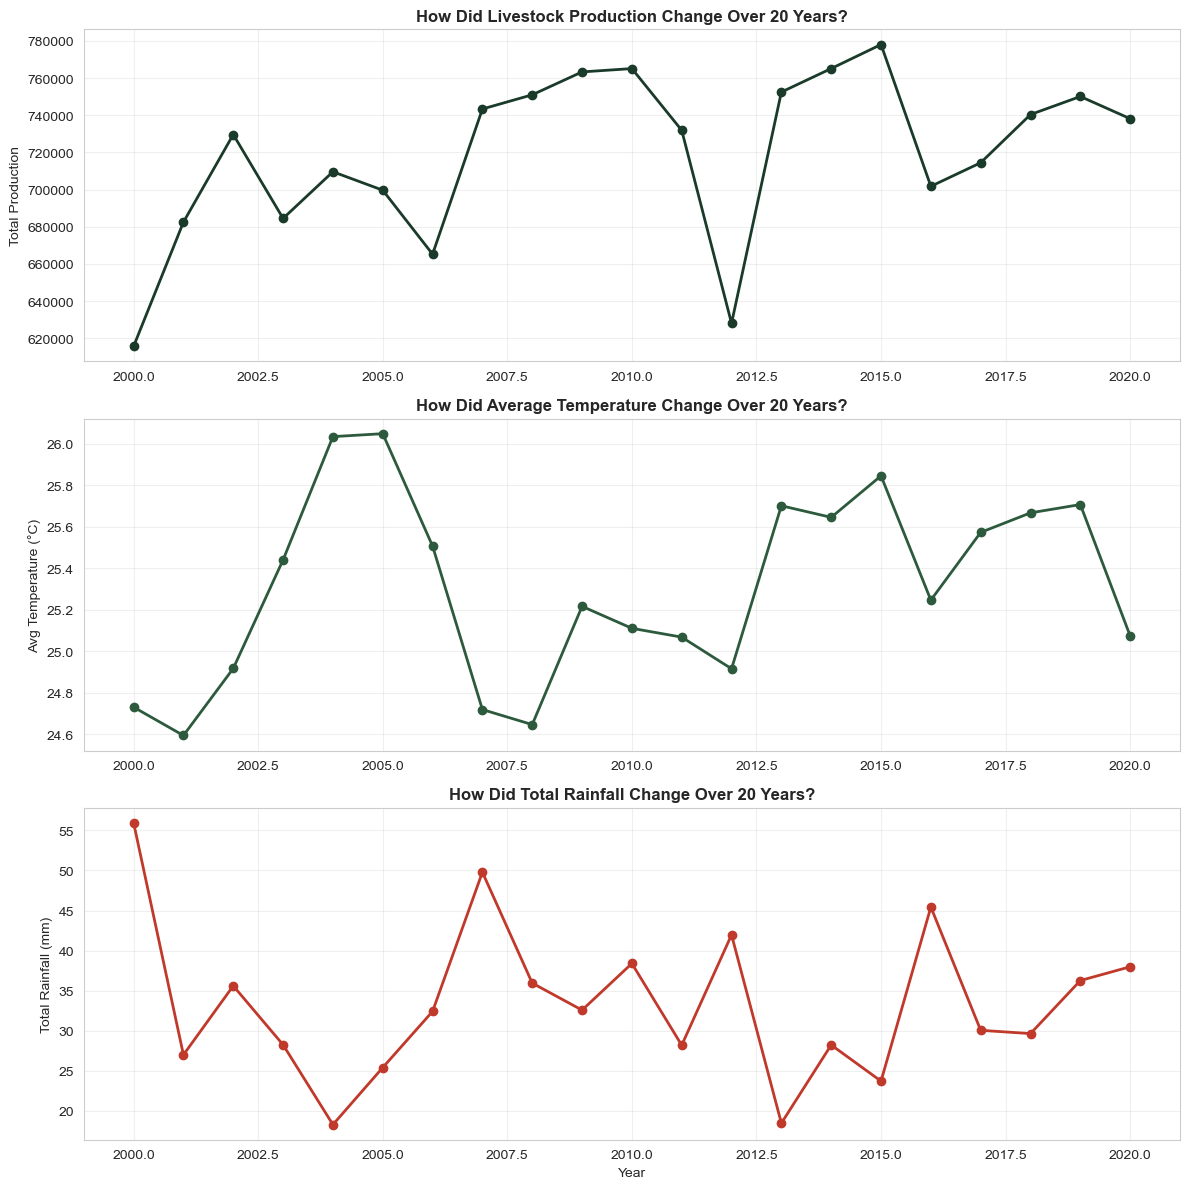

Chart 1 saved!


In [15]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

colors = ['#1A3A2A', '#2D5A3D', '#C0392B']

axes[0].plot(df['Year'], df['Production'], 
             marker='o', color=colors[0], linewidth=2)
axes[0].set_title('How Did Livestock Production Change Over 20 Years?',
                   fontweight='bold', fontsize=12)
axes[0].set_ylabel('Total Production')
axes[0].grid(alpha=0.3)

axes[1].plot(df['Year'], df['Avg_Temperature'], 
             marker='o', color=colors[1], linewidth=2)
axes[1].set_title('How Did Average Temperature Change Over 20 Years?',
                   fontweight='bold', fontsize=12)
axes[1].set_ylabel('Avg Temperature (°C)')
axes[1].grid(alpha=0.3)

axes[2].plot(df['Year'], df['Total_Rainfall'], 
             marker='o', color=colors[2], linewidth=2)
axes[2].set_title('How Did Total Rainfall Change Over 20 Years?',
                   fontweight='bold', fontsize=12)
axes[2].set_ylabel('Total Rainfall (mm)')
axes[2].set_xlabel('Year')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart1_trends_over_time.png', dpi=300)
plt.show()
print("Chart 1 saved!")

# Correlation Analysis

In [17]:
r_temp, p_temp = stats.pearsonr(df['Avg_Temperature'], df['Production'])
r_rain, p_rain = stats.pearsonr(df['Total_Rainfall'], df['Production'])
r_year, p_year = stats.pearsonr(df['Year'], df['Production'])

print("=" * 55)
print("PEARSON CORRELATION RESULTS")
print("=" * 55)
print(f"Temperature vs Production: r = {r_temp:.3f}, p = {p_temp:.4f}")
print(f"Rainfall vs Production:    r = {r_rain:.3f}, p = {p_rain:.4f}")
print(f"Year vs Production:        r = {r_year:.3f}, p = {p_year:.4f}")
print()

def interpret(p):
    return "Statistically Significant" if p < 0.05 else "Not Significant"

print(f"Temperature correlation is: {interpret(p_temp)}")
print(f"Rainfall correlation is:    {interpret(p_rain)}")
print(f"Year trend is:              {interpret(p_year)}")

PEARSON CORRELATION RESULTS
Temperature vs Production: r = 0.259, p = 0.2570
Rainfall vs Production:    r = -0.368, p = 0.1011
Year vs Production:        r = 0.475, p = 0.0296

Temperature correlation is: Not Significant
Rainfall correlation is:    Not Significant
Year trend is:              Statistically Significant


# Correlation Heatmap

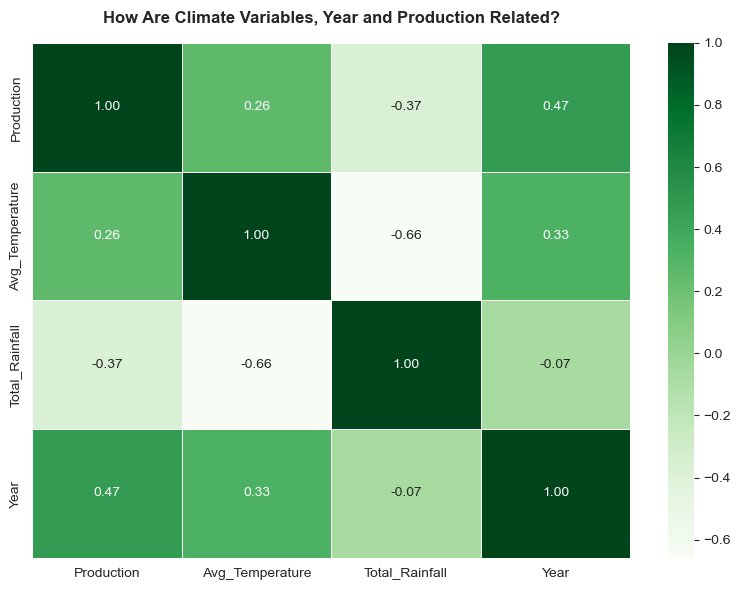

Chart 2 saved!


In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

corr_matrix = df[['Production', 'Avg_Temperature', 
                       'Total_Rainfall', 'Year']].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
            cmap='Greens', ax=ax, linewidths=0.5)

ax.set_title('How Are Climate Variables, Year and Production Related?',
              fontweight='bold', fontsize=12, pad=15)

plt.tight_layout()
plt.savefig('chart2_correlation_heatmap.png', dpi=300)
plt.show()
print("Chart 2 saved!")

# Simple Linear Regression

In [21]:
# Temperature -> Production
slope_t, intercept_t, r_t, p_t, se_t = stats.linregress(
    df['Avg_Temperature'], df['Production']
)

print("=" * 55)
print("SIMPLE REGRESSION: Temperature -> Production")
print("=" * 55)
print(f"Equation: Production = {intercept_t:.2f} + {slope_t:.2f} * Temperature")
print(f"R-squared: {r_t**2:.4f}")
print(f"P-value: {p_t:.4f}")
print(f"Result: {'Significant' if p_t < 0.05 else 'Not Significant'}")

print()

# Rainfall -> Production
slope_r, intercept_r, r_r, p_r, se_r = stats.linregress(
    df['Total_Rainfall'], df['Production']
)

print("=" * 55)
print("SIMPLE REGRESSION: Rainfall -> Production")
print("=" * 55)
print(f"Equation: Production = {intercept_r:.2f} + {slope_r:.2f} * Rainfall")
print(f"R-squared: {r_r**2:.4f}")
print(f"P-value: {p_r:.4f}")
print(f"Result: {'Significant' if p_r < 0.05 else 'Not Significant'}")

SIMPLE REGRESSION: Temperature -> Production
Equation: Production = 78734.34 + 25321.95 * Temperature
R-squared: 0.0671
P-value: 0.2570
Result: Not Significant

SIMPLE REGRESSION: Rainfall -> Production
Equation: Production = 776725.59 + -1717.59 * Rainfall
R-squared: 0.1352
P-value: 0.1011
Result: Not Significant


# Regression Line Plot

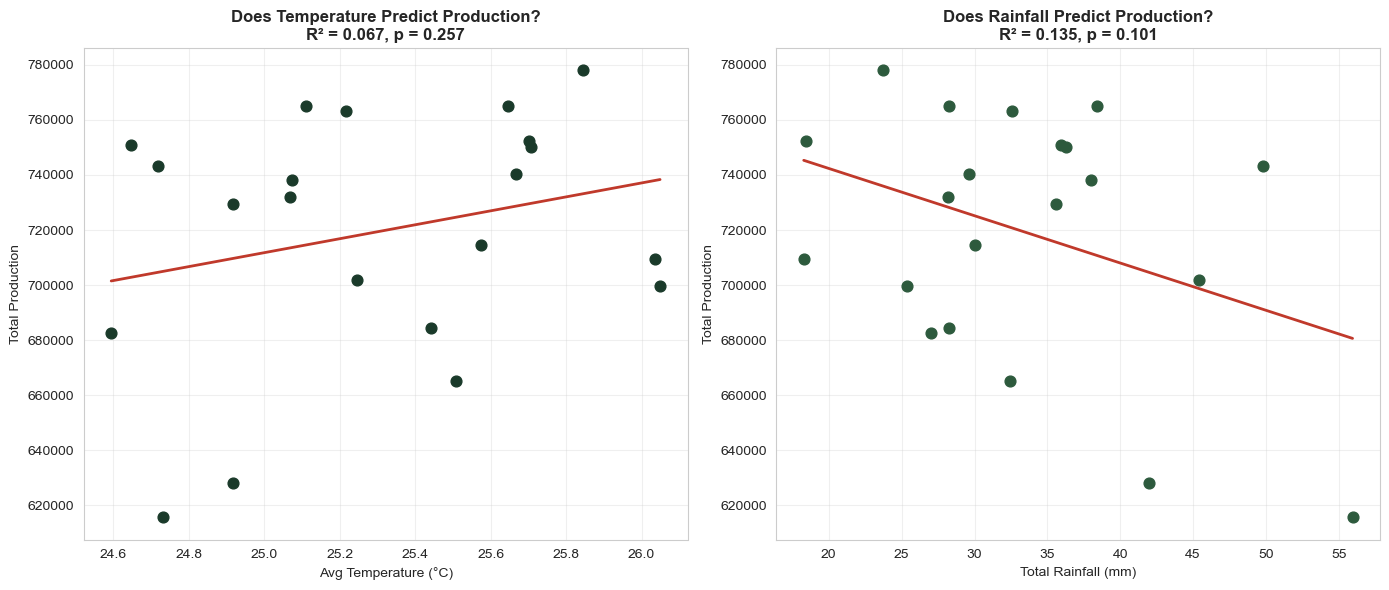

Chart 3 saved!


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Temperature regression plot
axes[0].scatter(df['Avg_Temperature'], df['Production'], 
                 color='#1A3A2A', s=60)
x_temp = np.array([df['Avg_Temperature'].min(), 
                    df['Avg_Temperature'].max()])
y_temp = intercept_t + slope_t * x_temp
axes[0].plot(x_temp, y_temp, color='#C0392B', linewidth=2)
axes[0].set_title(f'Does Temperature Predict Production?\nR² = {r_t**2:.3f}, p = {p_t:.3f}',
                   fontweight='bold')
axes[0].set_xlabel('Avg Temperature (°C)')
axes[0].set_ylabel('Total Production')
axes[0].grid(alpha=0.3)

# Rainfall regression plot
axes[1].scatter(df['Total_Rainfall'], df['Production'], 
                 color='#2D5A3D', s=60)
x_rain = np.array([df['Total_Rainfall'].min(), 
                    df['Total_Rainfall'].max()])
y_rain = intercept_r + slope_r * x_rain
axes[1].plot(x_rain, y_rain, color='#C0392B', linewidth=2)
axes[1].set_title(f'Does Rainfall Predict Production?\nR² = {r_r**2:.3f}, p = {p_r:.3f}',
                   fontweight='bold')
axes[1].set_xlabel('Total Rainfall (mm)')
axes[1].set_ylabel('Total Production')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart3_regression_plots.png', dpi=300)
plt.show()
print("Chart 3 saved!")

# Multiple Linear Regression

In [39]:
X = df[['Avg_Temperature', 'Total_Rainfall']].values
X = np.column_stack([np.ones(len(X)), X])
y = df['Production'].values

coeffs, residuals, rank, sv = np.linalg.lstsq(X, y, rcond=None)
y_pred = X @ coeffs

ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2_multi = 1 - ss_res / ss_tot

print("=" * 55)
print("MULTIPLE REGRESSION: Temperature + Rainfall -> Production")
print("=" * 55)
print(f"Intercept: {coeffs[0]:.2f}")
print(f"Temperature Coefficient: {coeffs[1]:.2f}")
print(f"Rainfall Coefficient: {coeffs[2]:.2f}")
print(f"R-squared: {r2_multi:.4f}")
print()
print(f"Interpretation: Temperature and Rainfall together explain "
      f"{r2_multi*100:.1f}% of the variation in livestock production")

MULTIPLE REGRESSION: Temperature + Rainfall -> Production
Intercept: 700182.40
Temperature Coefficient: 2904.50
Rainfall Coefficient: -1626.21
R-squared: 0.1357

Interpretation: Temperature and Rainfall together explain 13.6% of the variation in livestock production


# Production Trend Over the Year

In [42]:
slope_y, intercept_y, r_y, p_y, se_y = stats.linregress(
    df['Year'], df['Production']
)

print("=" * 55)
print("REGRESSION: Year -> Production")
print("=" * 55)
print(f"Equation: Production = {intercept_y:.2f} + {slope_y:.2f} * Year")
print(f"R-squared: {r_y**2:.4f}")
print(f"P-value: {p_y:.4f}")
print(f"Result: {'Significant' if p_y < 0.05 else 'Not Significant'}")
print()
print(f"Interpretation: Production is rising by approximately "
      f"{slope_y:.0f} units per year, independent of temperature "
      f"or rainfall.")

REGRESSION: Year -> Production
Equation: Production = -6131086.31 + 3408.26 * Year
R-squared: 0.2255
P-value: 0.0296
Result: Significant

Interpretation: Production is rising by approximately 3408 units per year, independent of temperature or rainfall.


# Year Trend Plot

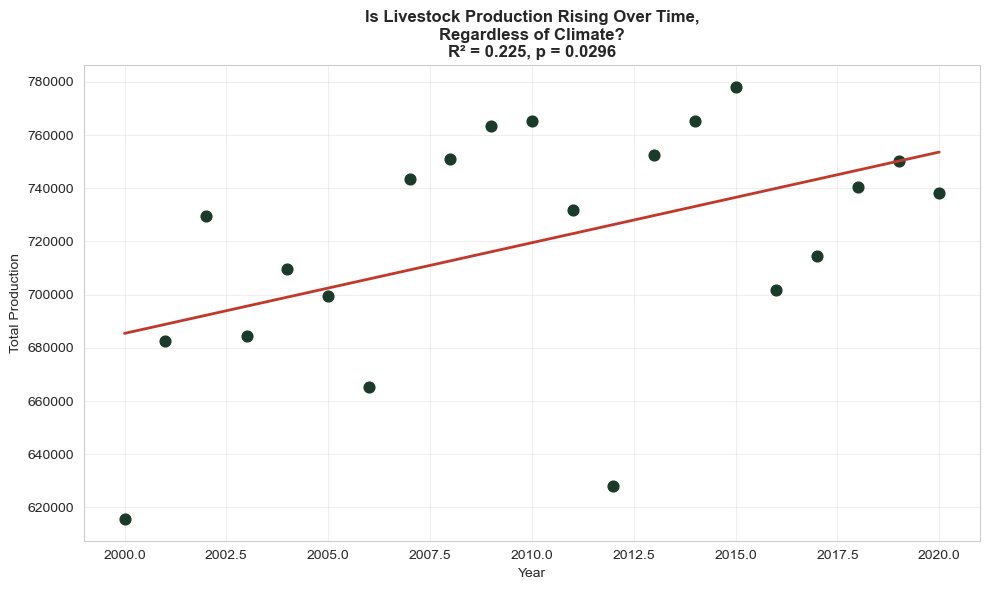

Chart 4 saved!


In [46]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['Year'], df['Production'], 
           color='#1A3A2A', s=60)

x_year = np.array([df['Year'].min(), df['Year'].max()])
y_year = intercept_y + slope_y * x_year
ax.plot(x_year, y_year, color='#C0392B', linewidth=2)

ax.set_title(f'Is Livestock Production Rising Over Time,\nRegardless of Climate?\nR² = {r_y**2:.3f}, p = {p_y:.4f}',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Total Production')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart4_year_trend.png', dpi=300)
plt.show()
print("Chart 4 saved!")

# Summary and Export

In [51]:
summary = pd.DataFrame({
    'Predictor': ['Temperature', 'Rainfall', 'Year'],
    'R_squared': [r_t**2, r_r**2, r_y**2],
    'P_value': [p_t, p_r, p_y],
    'Significant': [p_t < 0.05, p_r < 0.05, p_y < 0.05]
})

print(summary.to_string(index=False))
print()

import os
if not os.path.exists('outputs'):
    os.makedirs('outputs')

df.to_csv('outputs/merged_climate_livestock.csv', index=False)
summary.to_csv('outputs/regression_summary.csv', index=False)

import shutil
charts = ['chart1_trends_over_time.png', 'chart2_correlation_heatmap.png',
          'chart3_regression_plots.png', 'chart4_year_trend.png']
for chart in charts:
    if os.path.exists(chart):
        shutil.move(chart, f'outputs/{chart}')

print("All results and charts exported to outputs folder!")

  Predictor  R_squared  P_value  Significant
Temperature   0.067054 0.257024        False
   Rainfall   0.135181 0.101062        False
       Year   0.225450 0.029629         True

All results and charts exported to outputs folder!
